<a href="https://colab.research.google.com/github/budennovsk/GLM-vs-liner_model/blob/budennovsk%2Fpythonanywere/GLM_vs_liner_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAE (Пуассоновская регрессия): 15.37
MAE (OLS): 70.13
Pseudo R² (Пуассон): 0.9477
R² (OLS): 0.6163


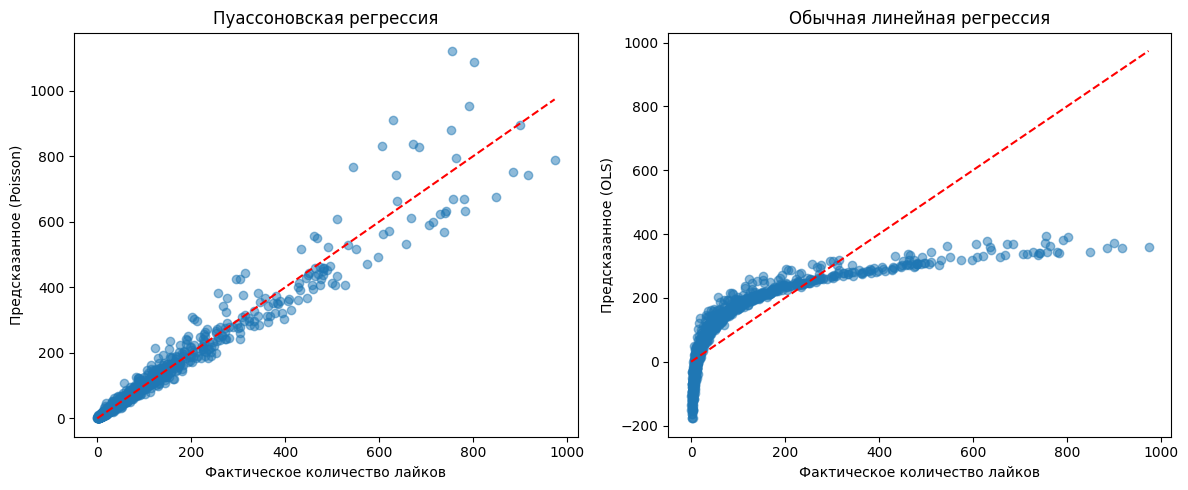

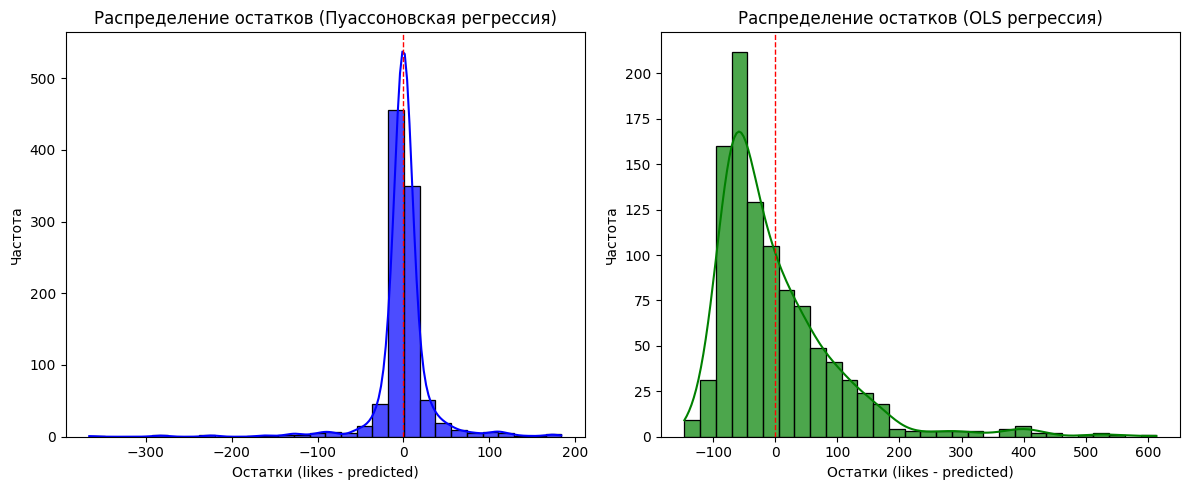

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# --- ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ ---
np.random.seed(42)
n_samples = 1000
post_length = np.random.randint(20, 500, n_samples)  # Длина поста в символах
time_of_day = np.random.randint(0, 24, n_samples)    # Время публикации (0-23 часа)

# Ожидаемое количество лайков (экспоненциальная зависимость)
expected_likes = np.exp(0.01 * post_length + 0.1 * (20 - np.abs(time_of_day - 20)))

# Генерация фактического количества лайков из Пуассоновского распределения
likes = np.random.poisson(expected_likes)

# Создание DataFrame
data = pd.DataFrame({
    'post_length': post_length,
    'time_of_day': time_of_day,
    'likes': likes
})

# Добавление константы для обеих моделей
data['intercept'] = 1

# Определение зависимой и независимых переменных
X = data[['intercept', 'post_length', 'time_of_day']]
y = data['likes']

# --- МОДЕЛЬ 1: ПУАССОНОВСКАЯ РЕГРЕССИЯ ---
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
data['predicted_likes_poisson'] = poisson_model.predict(X)

# --- МОДЕЛЬ 2: Обычная ЛИНЕЙНАЯ РЕГРЕССИЯ (OLS) ---
ols_model = sm.OLS(y, X).fit()
data['predicted_likes_ols'] = ols_model.predict(X)

# --- ОЦЕНКА ТОЧНОСТИ ---
# 1. MAE (Средняя абсолютная ошибка)
mae_poisson = mean_absolute_error(data['likes'], data['predicted_likes_poisson'])
mae_ols = mean_absolute_error(data['likes'], data['predicted_likes_ols'])

# 2. Pseudo-R² (Макфаддена) для Пуассона
llf_poisson = poisson_model.llf  # Логарифм правдоподобия модели
llnull_poisson = poisson_model.llnull  # Логарифм правдоподобия нулевой модели
pseudo_r2_poisson = 1 - (llf_poisson / llnull_poisson)

# 3. Обычный R² для OLS
r2_ols = r2_score(data['likes'], data['predicted_likes_ols'])

# --- ВЫВОД МЕТРИК ---
print(f"MAE (Пуассоновская регрессия): {mae_poisson:.2f}")
print(f"MAE (OLS): {mae_ols:.2f}")
print(f"Pseudo R² (Пуассон): {pseudo_r2_poisson:.4f}")
print(f"R² (OLS): {r2_ols:.4f}")

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(12, 5))

# Фактические vs. предсказанные Пуассоном
plt.subplot(1, 2, 1)
plt.scatter(data['likes'], data['predicted_likes_poisson'], alpha=0.5)
plt.xlabel('Фактическое количество лайков')
plt.ylabel('Предсказанное (Poisson)')
plt.title('Пуассоновская регрессия')
plt.plot([0, max(data['likes'])], [0, max(data['likes'])], color='red', linestyle='--')

# Фактические vs. предсказанные OLS
plt.subplot(1, 2, 2)
plt.scatter(data['likes'], data['predicted_likes_ols'], alpha=0.5)
plt.xlabel('Фактическое количество лайков')
plt.ylabel('Предсказанное (OLS)')
plt.title('Обычная линейная регрессия')
plt.plot([0, max(data['likes'])], [0, max(data['likes'])], color='red', linestyle='--')

plt.tight_layout()
plt.show()

import seaborn as sns


# --- ВЫЧИСЛЕНИЕ ОСТАТКОВ ---
data['residuals_poisson'] = data['likes'] - data['predicted_likes_poisson']
data['residuals_ols'] = data['likes'] - data['predicted_likes_ols']


# Гистограммы остатков
plt.figure(figsize=(12, 5))

# Остатки Пуассоновской модели
plt.subplot(1, 2, 1)
sns.histplot(data['residuals_poisson'], bins=30, kde=True, color='blue', alpha=0.7)
plt.axvline(data['residuals_poisson'].mean(), color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Остатки (likes - predicted)')
plt.ylabel('Частота')
plt.title('Распределение остатков (Пуассоновская регрессия)')

# Остатки OLS модели
plt.subplot(1, 2, 2)
sns.histplot(data['residuals_ols'], bins=30, kde=True, color='green', alpha=0.7)
plt.axvline(data['residuals_ols'].mean(), color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Остатки (likes - predicted)')
plt.ylabel('Частота')
plt.title('Распределение остатков (OLS регрессия)')

plt.tight_layout()
plt.show()


In [5]:
data['likes'], data['predicted_likes_ols']

(0        4
 1      598
 2      145
 3       54
 4        8
       ... 
 995     34
 996      6
 997     18
 998    138
 999    160
 Name: likes, Length: 1000, dtype: int64,
 0     -100.245998
 1      319.990709
 2      199.435559
 3      135.983365
 4      -72.101265
           ...    
 995     83.265216
 996    -31.919563
 997     61.949108
 998    196.026269
 999    221.561808
 Name: predicted_likes_ols, Length: 1000, dtype: float64)

In [6]:
data['likes'], data['predicted_likes_poisson']

(0        4
 1      598
 2      145
 3       54
 4        8
       ... 
 995     34
 996      6
 997     18
 998    138
 999    160
 Name: likes, Length: 1000, dtype: int64,
 0        4.001570
 1      492.756160
 2      125.871728
 3       57.758238
 4        5.336500
           ...    
 995     26.943848
 996      7.639767
 997     19.205483
 998    149.124455
 999    162.015132
 Name: predicted_likes_poisson, Length: 1000, dtype: float64)